In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_market_data
from src.pca import fit_pca

from src.backtest import run_backtest

from src.metrics import (
    equity_curve,
    drawdown_series,
    performance_summary
)

# Load the consistent dataset

In [2]:
prices, stock_returns, hedge_returns = load_market_data()

print("Prices:", prices.shape)
print("Stock returns:", stock_returns.shape)
print("Hedge returns:", hedge_returns.shape)

stock_returns.head()

Prices: (1940, 21)
Stock returns: (1939, 20)
Hedge returns: (1939,)


Ticker,AAPL,MSFT,NVDA,GOOGL,META,JPM,BAC,GS,XOM,CVX,JNJ,PFE,WMT,COST,BA,CAT,KO,PEP,DIS,NFLX
Date,,,,,,,,,,,,,,,,,,,,
2019-01-03,-0.099607,-0.036788,-0.060417,-0.027696,-0.029039,-0.014212,-0.016026,-0.014649,-0.015354,-0.019153,-0.015891,-0.027977,-0.005143,-0.021196,-0.039869,-0.038534,-0.006180,-0.009334,-0.024227,0.013226
2019-01-04,0.042689,0.046509,0.064068,0.051294,0.047138,0.036866,0.041531,0.032683,0.036869,0.020724,0.016783,0.022835,0.006246,0.029039,0.052042,0.054646,0.019940,0.020506,0.030847,0.097234
2019-01-07,-0.002226,0.001275,0.052941,-0.001994,0.000725,0.000695,-0.000782,0.005541,0.005200,0.012994,-0.006414,0.005349,0.011772,0.003685,0.003149,0.000624,-0.013033,-0.008599,0.008667,0.059717
2019-01-08,0.019063,0.007251,-0.024895,0.008783,0.032452,-0.001886,-0.001956,-0.003693,0.007271,-0.004365,0.023226,0.004626,0.006981,0.007488,0.037853,0.012010,0.011289,0.009587,0.007779,0.015634
2019-01-09,0.016981,0.014299,0.019667,-0.003427,0.011927,-0.001690,0.009800,0.006272,0.005275,0.013420,-0.007926,-0.002072,-0.003256,0.006473,0.009691,0.003853,-0.019166,-0.027944,0.011219,-0.000968


In [3]:
stock_returns.describe()

Ticker,AAPL,MSFT,NVDA,GOOGL,META,JPM,BAC,GS,XOM,CVX,JNJ,PFE,WMT,COST,BA,CAT,KO,PEP,DIS,NFLX
count,1939.000000,1939.000000,1939.000000,1939.000000,1939.000000,1939.000000,1939.000000,1939.000000,1939.000000,1939.000000,1939.000000,1939.000000,1939.000000,1939.000000,1939.000000,1939.000000,1939.000000,1939.000000,1939.000000,1939.000000
mean,0.001324,0.001033,0.002678,0.001185,0.001235,0.000931,0.000736,0.001180,0.000791,0.000688,0.000569,0.000121,0.000797,0.000918,0.000184,0.001257,0.000518,0.000302,0.000197,0.000883
std,0.019345,0.018416,0.031817,0.019822,0.026529,0.018443,0.020290,0.020113,0.019483,0.019945,0.012175,0.016229,0.014180,0.014245,0.028800,0.020609,0.012497,0.013367,0.019929,0.026568
min,-0.128647,-0.147390,-0.184521,-0.116341,-0.263901,-0.149649,-0.153973,-0.127053,-0.122248,-0.221248,-0.075917,-0.077346,-0.113757,-0.124513,-0.238484,-0.142822,-0.096725,-0.114283,-0.131632,-0.351166
25%,-0.007729,-0.007834,-0.015040,-0.008930,-0.011273,-0.007608,-0.008932,-0.008795,-0.009543,-0.008126,-0.005405,-0.008964,-0.006014,-0.006217,-0.012710,-0.009623,-0.005474,-0.005908,-0.008885,-0.011612
50%,0.001317,0.001101,0.002904,0.001328,0.001062,0.001163,0.000674,0.000858,0.000695,0.001005,0.000497,-0.000266,0.000886,0.001077,-0.000276,0.001106,0.000687,0.000278,-0.000116,0.000398
75%,0.011315,0.010421,0.019821,0.011291,0.013773,0.009487,0.010587,0.011392,0.011121,0.009550,0.006563,0.008483,0.007575,0.008357,0.012794,0.012211,0.006481,0.006711,0.009286,0.013517
max,0.153289,0.155067,0.243697,0.102244,0.232824,0.180125,0.177962,0.175803,0.126868,0.227407,0.079977,0.108552,0.117085,0.099595,0.243186,0.116346,0.064796,0.129366,0.144123,0.168543


In [4]:
stock_returns.isna().sum().sum()

np.int64(0)

# first full-sample PCA only for exploration

In [5]:
X = stock_returns.to_numpy()

mean, eigenvalues, eigenvectors, evr, Q_k = fit_pca(
    X,
    k=6
)

print("Eigenvalues:")
print(eigenvalues)

print("\nExplained variance ratio:")
print(evr)

print("\nCumulative explained variance:")
print(np.cumsum(evr))

Eigenvalues:
[3.40711734e-03 1.14109963e-03 5.25017165e-04 4.69259436e-04
 4.08326126e-04 3.85211935e-04 3.35613122e-04 2.23437142e-04
 2.10393563e-04 2.00746267e-04 1.99503159e-04 1.51684417e-04
 1.22366006e-04 1.13729948e-04 8.11321142e-05 7.44741057e-05
 7.09305785e-05 5.50284732e-05 4.64401860e-05 4.23792227e-05]

Explained variance ratio:
[0.41228978 0.13808263 0.06353148 0.05678433 0.04941089 0.04661388
 0.040612   0.02703777 0.02545939 0.02429198 0.02414156 0.01835509
 0.01480731 0.01376228 0.00981767 0.00901199 0.00858319 0.00665891
 0.00561965 0.00512824]

Cumulative explained variance:
[0.41228978 0.5503724  0.61390389 0.67068821 0.7200991  0.76671297
 0.80732498 0.83436275 0.85982213 0.88411411 0.90825567 0.92661076
 0.94141807 0.95518035 0.96499801 0.97401    0.9825932  0.98925211
 0.99487176 1.        ]


# Plot explained variance

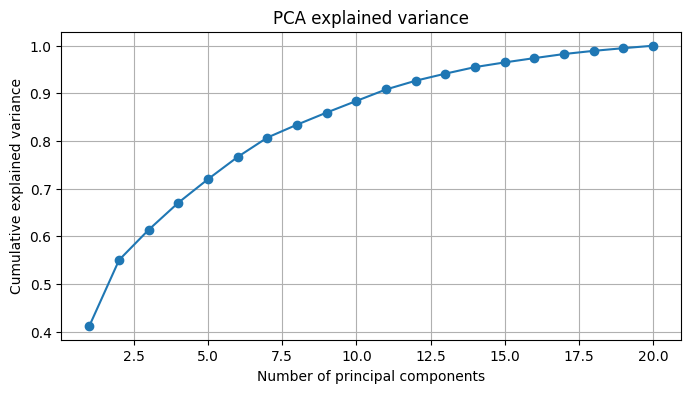

In [6]:
plt.figure(figsize=(8, 4))

plt.plot(
    range(1, len(evr) + 1),
    np.cumsum(evr),
    marker="o"
)

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance")
plt.grid()

plt.show()

# Backtest

In [7]:
results = run_backtest(
    stock_returns=stock_returns,
    pca_window=252,
    k=6,
    spread_window=25,
    z_window=252,
    entry_z=2.5,
    max_holding=20,
    position_size=0.05,
    max_positions=10,
    max_gross=0.50,
    cost_bps=10,
    rebalance_interval=20
)

performance = results["performance"]

In [8]:
performance = results["performance"]

performance.tail(10)

,gross_return,transaction_cost,net_return,turnover,raw_turnover,extra_pca_turnover,net_exposure,gross_exposure,active_positions,max_factor_exposure,rebalanced,pc1_share,pc1_threshold,high_pc1_regime,new_entries_allowed
date,,,,,,,,,,,,,,,
2026-09-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0.230294,0.406874,False,False
2026-09-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0.229413,0.406423,False,False
2026-09-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0.229822,0.405938,False,False
2026-09-11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0.229153,0.405031,False,False
2026-09-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0.229266,0.403949,False,False
2026-09-15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0.230023,0.403274,False,False
2026-09-16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0.229736,0.402888,False,False
2026-09-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0.229837,0.402479,False,False
2026-09-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0.229018,0.402165,False,False


In [9]:
performance[
    [
        "net_exposure",
        "gross_exposure",
        "active_positions",
        "turnover"
    ]
].describe()

,net_exposure,gross_exposure,active_positions,turnover
count,1410.000000,1410.000000,1410.000000,1410.000000
mean,0.003218,0.052109,0.715603,0.007564
std,0.014635,0.084473,1.347120,0.029197
min,-0.017956,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.098505,1.000000,0.000000
max,0.113946,0.365179,8.000000,0.245694


In [10]:
results["zscores"].tail()

Ticker,AAPL,MSFT,NVDA,GOOGL,META,JPM,BAC,GS,XOM,CVX,JNJ,PFE,WMT,COST,BA,CAT,KO,PEP,DIS,NFLX
Date,,,,,,,,,,,,,,,,,,,,
2026-09-15,1.013387,-0.317505,-0.135828,-0.755634,0.511139,-0.018732,-1.237386,0.181328,-0.744580,0.560216,-0.118901,0.726691,-0.652062,-1.389007,0.190657,-0.319649,-0.736806,-0.124896,1.172383,0.435849
2026-09-16,1.452774,-0.307004,-0.084961,-0.600635,0.341312,0.303825,-1.219372,0.089395,-0.926313,0.310491,0.105508,1.170381,-0.893230,-1.374122,-0.945929,-0.463460,-0.859595,-0.377040,1.451581,0.204185
2026-09-17,1.793236,0.091664,-0.605072,-0.436924,0.425167,0.080940,-1.422241,0.198142,-0.891289,0.322698,0.428612,1.548833,-1.273274,-1.339435,-1.419863,-0.180413,-0.755552,-0.446683,1.199390,0.029224
2026-09-18,1.862512,0.190409,-0.426081,0.005533,0.305161,0.360375,-1.192196,-0.169567,-0.455717,0.306985,0.523391,1.444927,-1.022216,-1.253704,-0.948633,-0.410756,-0.461742,-1.010257,1.005690,-0.367649
2026-09-21,1.765670,0.290118,-0.538227,-0.387524,0.420399,0.454187,-1.338634,0.069261,-0.581081,0.146466,0.778316,1.520189,-0.787769,-1.095019,-1.201822,-0.271644,-0.794826,-1.048594,0.729207,-0.035300


In [11]:
results["positions"].tail()

Ticker,AAPL,MSFT,NVDA,GOOGL,META,JPM,BAC,GS,XOM,CVX,JNJ,PFE,WMT,COST,BA,CAT,KO,PEP,DIS,NFLX
2026-09-14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2026-09-15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2026-09-16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2026-09-17,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2026-09-18,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [12]:
results["weights"].tail()

Ticker,AAPL,MSFT,NVDA,GOOGL,META,JPM,BAC,GS,XOM,CVX,JNJ,PFE,WMT,COST,BA,CAT,KO,PEP,DIS,NFLX
2026-09-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-09-15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-09-16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-09-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-09-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
performance_summary(performance)

Cumulative Return           0.007130
Annualized Volatility       0.008900
Sharpe Ratio                0.147128
Max Drawdown               -0.016670
Average Daily Turnover      0.007564
Total Transaction Costs     0.010666
Average Gross Exposure      0.052109
Average Active Positions    0.715603
dtype: float64

# Without transaction costs

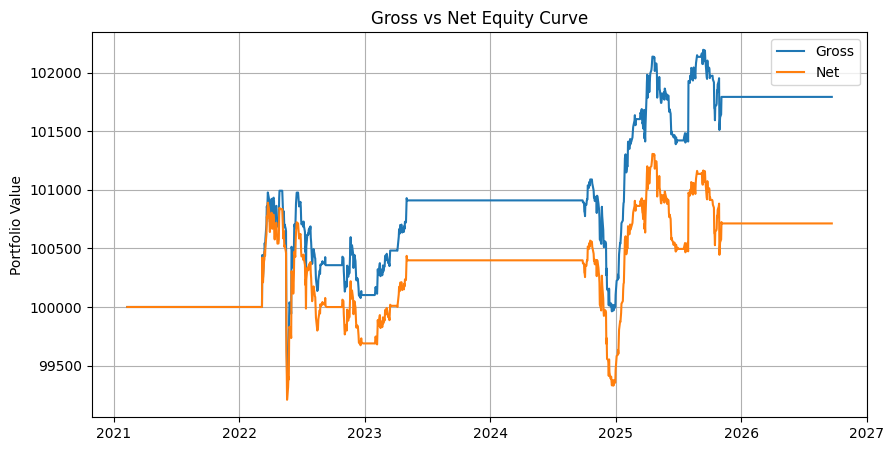

In [14]:
gross_equity = equity_curve(
    performance["gross_return"]
)

net_equity = equity_curve(
    performance["net_return"]
)

plt.figure(figsize=(10, 5))

plt.plot(gross_equity, label="Gross")
plt.plot(net_equity, label="Net")

plt.title("Gross vs Net Equity Curve")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()

plt.show()

In [15]:
gross_summary = performance_summary(
    performance.assign(
        net_return=performance["gross_return"],
        transaction_cost=0.0
    )
)

gross_summary

Cumulative Return           0.017928
Annualized Volatility       0.008925
Sharpe Ratio                0.360279
Max Drawdown               -0.015747
Average Daily Turnover      0.007564
Total Transaction Costs     0.000000
Average Gross Exposure      0.052109
Average Active Positions    0.715603
dtype: float64

# Rebalance interval

In [16]:
rebalance_values = [1, 5, 10, 20]

rows = []

for interval in rebalance_values:

    test_results = run_backtest(
        stock_returns=stock_returns,
        pca_window=252,
        k=6,
        spread_window=20,
        z_window=252,
        entry_z=2.5,
        max_holding=20,
        position_size=0.05,
        max_positions=10,
        max_gross=0.50,
        cost_bps=10,
        rebalance_interval=interval
    )

    perf = test_results["performance"]

    gross_summary = performance_summary(
        perf.assign(
            net_return=perf["gross_return"],
            transaction_cost=0.0
        )
    )

    net_summary = performance_summary(perf)

    rows.append({
        "rebalance_interval": interval,

        "gross_return":
            gross_summary["Cumulative Return"],

        "gross_sharpe":
            gross_summary["Sharpe Ratio"],

        "net_return":
            net_summary["Cumulative Return"],

        "net_sharpe":
            net_summary["Sharpe Ratio"],

        "avg_turnover":
            perf["turnover"].mean(),

        "total_cost":
            perf["transaction_cost"].sum(),

        "avg_factor_exposure":
            perf["max_factor_exposure"].mean(),

        "rebalance_fraction":
            perf["rebalanced"].mean()
    })

rebalance_test = pd.DataFrame(rows)

rebalance_test

,rebalance_interval,gross_return,gross_sharpe,net_return,net_sharpe,avg_turnover,total_cost,avg_factor_exposure,rebalance_fraction
0,1,0.005018,0.106195,-0.008492,-0.168702,0.009564,0.013533,8.574306e-18,1.000000
1,5,0.005971,0.124934,-0.006329,-0.123888,0.008693,0.012301,3.526802e-04,0.233922
2,10,0.006648,0.138287,-0.005193,-0.100540,0.008362,0.011832,4.954008e-04,0.141343
3,20,0.008744,0.180482,-0.002969,-0.055594,0.008253,0.011678,6.116753e-04,0.101767


# check separate years

In [17]:
train_perf = performance.loc[: "2023-12-31"]
test_perf = performance.loc["2024-01-01":]

print("TRAIN")
print(performance_summary(train_perf))

print("\nTEST")
print(performance_summary(test_perf))

TRAIN
Cumulative Return           0.003982
Annualized Volatility       0.009421
Sharpe Ratio                0.150728
Max Drawdown               -0.016670
Average Daily Turnover      0.006979
Total Transaction Costs     0.005081
Average Gross Exposure      0.045911
Average Active Positions    0.653846
dtype: float64

TEST
Cumulative Return           0.003136
Annualized Volatility       0.008315
Sharpe Ratio                0.143287
Max Drawdown               -0.012311
Average Daily Turnover      0.008189
Total Transaction Costs     0.005585
Average Gross Exposure      0.058725
Average Active Positions    0.781525
dtype: float64


In [18]:
train_returns = stock_returns.loc[: "2023-12-31"]

spread_values = [5, 10, 15, 20, 25, 30, 40]

rows = []

for H in spread_values:

    train_results = run_backtest(
        stock_returns=train_returns,
        pca_window=252,
        k=6,
        spread_window=H,
        z_window=252,
        entry_z=2.5,
        max_holding=20,
        position_size=0.10,
        max_positions=5,
        max_gross=0.50,
        cost_bps=10,
        rebalance_interval=20
    )

    perf = train_results["performance"]

    summary = performance_summary(perf)

    rows.append({
        "spread_window": H,
        "net_return": summary["Cumulative Return"],
        "net_sharpe": summary["Sharpe Ratio"],
        "turnover": perf["turnover"].mean()
    })

train_H_test = pd.DataFrame(rows)

train_H_test

,spread_window,net_return,net_sharpe,turnover
0,5,-0.049753,-0.926553,0.028525
1,10,-0.021673,-0.411069,0.019073
2,15,-0.020266,-0.386025,0.015196
3,20,-0.002275,-0.037417,0.013077
4,25,-0.005096,-0.087326,0.012331
5,30,0.010475,0.214560,0.014280
6,40,0.039187,0.776074,0.015168


In [19]:
position_configs = [
    (10, 0.05),
    (5, 0.10),
    (1, 0.5),
]

rows = []

for max_pos, pos_size in position_configs:

    train_results = run_backtest(
        stock_returns=train_returns,
        pca_window=252,
        k=6,
        spread_window=25,
        z_window=252,
        entry_z=2.5,
        max_holding=25,
        position_size=pos_size,
        max_positions=max_pos,
        max_gross=0.50,
        cost_bps=10,
        rebalance_interval=20
    )

    perf = train_results["performance"]

    summary = performance_summary(perf)

    rows.append({
        "max_positions": max_pos,
        "position_size": pos_size,
        "net_return": summary["Cumulative Return"],
        "net_sharpe": summary["Sharpe Ratio"],
        "max_drawdown": summary["Max Drawdown"],
        "avg_turnover": perf["turnover"].mean(),
        "avg_positions": perf["active_positions"].mean()
    })

position_test = pd.DataFrame(rows)

position_test

,max_positions,position_size,net_return,net_sharpe,max_drawdown,avg_turnover,avg_positions
0,10,0.05,0.005774,0.204877,-0.016552,0.006657,0.780220
1,5,0.10,0.000971,0.027302,-0.033863,0.011448,0.708791
2,1,0.50,-0.040203,-0.593598,-0.059452,0.013116,0.295330


In [20]:
final_results = run_backtest(
    stock_returns=stock_returns,
    pca_window=252,
    k=6,
    spread_window=40,
    z_window=252,
    entry_z=2.5,
    max_holding=20,
    position_size=0.10,
    max_positions=5,
    max_gross=0.50,
    cost_bps=10,
    rebalance_interval=20
)

final_perf = final_results["performance"]

train_perf = final_perf.loc[: "2023-12-31"]
test_perf = final_perf.loc["2024-01-01":]

In [21]:
test_gross = performance_summary(
    test_perf.assign(
        net_return=test_perf["gross_return"],
        transaction_cost=0.0
    )
)

test_net = performance_summary(test_perf)

print("TEST GROSS")
print(test_gross)

print("\nTEST NET")
print(test_net)

TEST GROSS
Cumulative Return           0.012300
Annualized Volatility       0.016360
Sharpe Ratio                0.284287
Max Drawdown               -0.026055
Average Daily Turnover      0.017094
Total Transaction Costs     0.000000
Average Gross Exposure      0.118509
Average Active Positions    0.788856
dtype: float64

TEST NET
Cumulative Return           0.000566
Annualized Volatility       0.016376
Sharpe Ratio                0.020953
Max Drawdown               -0.028240
Average Daily Turnover      0.017094
Total Transaction Costs     0.011658
Average Gross Exposure      0.118509
Average Active Positions    0.788856
dtype: float64


In [22]:
print("TRAIN NET")
print(performance_summary(train_perf))

TRAIN NET
Cumulative Return           0.039187
Annualized Volatility       0.017708
Sharpe Ratio                0.776074
Max Drawdown               -0.018565
Average Daily Turnover      0.015168
Total Transaction Costs     0.010815
Average Gross Exposure      0.107174
Average Active Positions    0.775596
dtype: float64


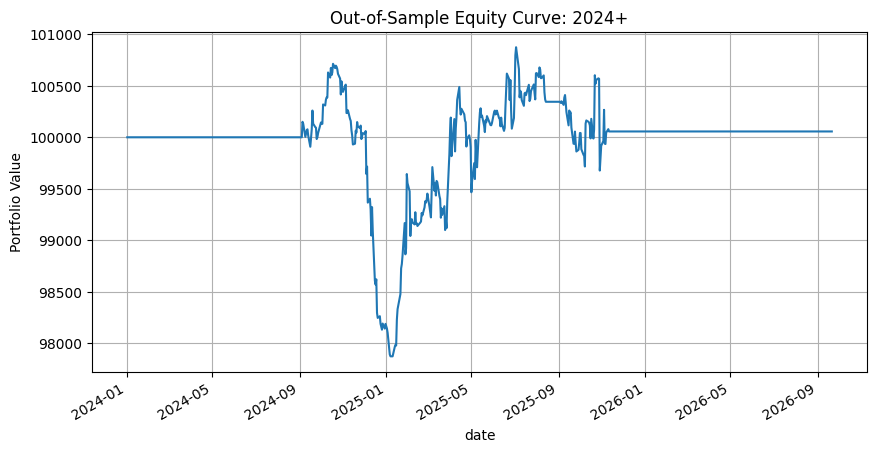

In [23]:
test_equity = equity_curve(
    test_perf["net_return"]
)

test_equity.plot(
    figsize=(10, 5),
    title="Out-of-Sample Equity Curve: 2024+"
)

plt.ylabel("Portfolio Value")
plt.grid()
plt.show()

# Added AR(1) model

In [24]:
rows = []

for use_ar in [False, True]:

    r = run_backtest(
        stock_returns=train_returns,
        pca_window=252,
        k=6,
        spread_window=40,
        z_window=252,

        use_ar1_filter=use_ar,
        ar_window=252,

        entry_z=2.5,
        max_holding=20,
        position_size=0.10,
        max_positions=5,

        max_gross=0.50,
        cost_bps=10,
        rebalance_interval=20
    )

    perf = r["performance"]

    summary = performance_summary(perf)

    rows.append({
        "ar1_filter": use_ar,
        "net_return":
            summary["Cumulative Return"],
        "net_sharpe":
            summary["Sharpe Ratio"],
        "max_drawdown":
            summary["Max Drawdown"],
        "turnover":
            perf["turnover"].mean(),
        "avg_positions":
            perf["active_positions"].mean()
    })

ar_test = pd.DataFrame(rows)

ar_test

,ar1_filter,net_return,net_sharpe,max_drawdown,turnover,avg_positions
0,False,0.039187,0.776074,-0.018565,0.015168,0.775596
1,True,0.030767,0.622471,-0.021075,0.016120,0.781206


In [25]:
ar_results = run_backtest(
    stock_returns=train_returns,
    use_ar1_filter=True,
    k=6,
    spread_window=40,
    entry_z=2.5,
    position_size=0.10,
    max_positions=5,
    rebalance_interval=20
)

ar_results["ar1_phi"].stack().describe()

count    15040.000000
mean         0.975123
std          0.020868
min          0.712817
25%          0.968102
50%          0.979831
75%          0.988726
max          1.043891
dtype: float64

In [26]:
use_ar1_filter=False

In [27]:
train_returns = stock_returns.loc[: "2023-12-31"]

In [28]:
signal_modes = [
    ("zscore", None),
    ("quantile_5pct", (0.025, 0.975)),
    ("quantile_10pct", (0.05, 0.95)),
]

rows = []

for name, quantiles in signal_modes:

    if quantiles is None:
        lower_q = 0.025
        upper_q = 0.975
        mode = "zscore"
    else:
        lower_q, upper_q = quantiles
        mode = "quantile"

    r = run_backtest(
        stock_returns=train_returns,

        pca_window=252,
        k=6,

        spread_window=40,

        signal_mode=mode,
        z_window=252,
        entry_z=2.5,

        lower_q=lower_q,
        upper_q=upper_q,

        use_ar1_filter=False,

        max_holding=20,
        position_size=0.10,
        max_positions=5,

        max_gross=0.50,
        cost_bps=10,
        rebalance_interval=20
    )

    perf = r["performance"]

    summary = performance_summary(perf)

    rows.append({
        "signal": name,
        "net_return":
            summary["Cumulative Return"],
        "net_sharpe":
            summary["Sharpe Ratio"],
        "max_drawdown":
            summary["Max Drawdown"],
        "turnover":
            perf["turnover"].mean(),
        "avg_positions":
            perf["active_positions"].mean()
    })

quantile_test = pd.DataFrame(rows)

quantile_test

,signal,net_return,net_sharpe,max_drawdown,turnover,avg_positions
0,zscore,0.039187,0.776074,-0.018565,0.015168,0.775596
1,quantile_5pct,-0.004375,-0.062227,-0.049117,0.026326,1.440393
2,quantile_10pct,0.032697,0.547116,-0.046828,0.030174,1.809257


In [29]:
final_results = run_backtest(
    stock_returns=stock_returns,
    pca_window=252,
    k=6,
    spread_window=40,

    signal_mode="zscore",
    z_window=252,
    entry_z=2.5,

    use_ar1_filter=False,

    max_holding=20,
    position_size=0.10,
    max_positions=5,

    max_gross=0.50,
    cost_bps=10,
    rebalance_interval=20
)

final_perf = final_results["performance"]

In [30]:
yearly_rows = []

for year in sorted(final_perf.index.year.unique()):

    year_perf = final_perf[
        final_perf.index.year == year
    ]

    summary = performance_summary(year_perf)

    yearly_rows.append({
        "year": year,
        "return": summary["Cumulative Return"],
        "sharpe": summary["Sharpe Ratio"],
        "max_drawdown": summary["Max Drawdown"],
        "turnover": year_perf["turnover"].mean(),
        "avg_positions": year_perf["active_positions"].mean()
    })

yearly_results = pd.DataFrame(yearly_rows)

yearly_results

,year,return,sharpe,max_drawdown,turnover,avg_positions
0,2021,0.000000,NaN,0.000000,0.000000,0.000000
1,2022,0.036358,1.236076,-0.018565,0.038302,2.039841
2,2023,0.002730,0.519847,-0.001554,0.004805,0.164000
3,2024,-0.018142,-1.565983,-0.025671,0.010656,0.658730
4,2025,0.019054,0.792911,-0.011887,0.035891,1.488000
5,2026,0.000000,NaN,0.000000,0.000000,0.000000


# Check PC1, top6 PC

In [31]:
pc_rows = []

for t in range(252, len(stock_returns)):

    date = stock_returns.index[t]

    train = stock_returns.iloc[
        t - 252:t
    ].to_numpy()

    (
        mean,
        eigenvalues,
        eigenvectors,
        evr,
        Q_k
    ) = fit_pca(
        train,
        k=6
    )

    pc_rows.append({
        "date": date,
        "pc1_share": evr[0],
        "top6_share": evr[:6].sum()
    })

rolling_pca_structure = (
    pd.DataFrame(pc_rows)
    .set_index("date")
)

rolling_pca_structure.head()

,pc1_share,top6_share
date,,
2020-01-03,0.420683,0.748704
2020-01-06,0.416168,0.747324
2020-01-07,0.399129,0.739355
2020-01-08,0.399280,0.739033
2020-01-09,0.400198,0.738178


In [32]:
yearly_pca = (
    rolling_pca_structure
    .groupby(rolling_pca_structure.index.year)
    .mean()
)

yearly_pca

,pc1_share,top6_share
date,,
2020,0.600382,0.860526
2021,0.407699,0.810693
2022,0.431939,0.815750
2023,0.459768,0.813667
2024,0.294356,0.716299
2025,0.409055,0.763193
2026,0.304294,0.678549


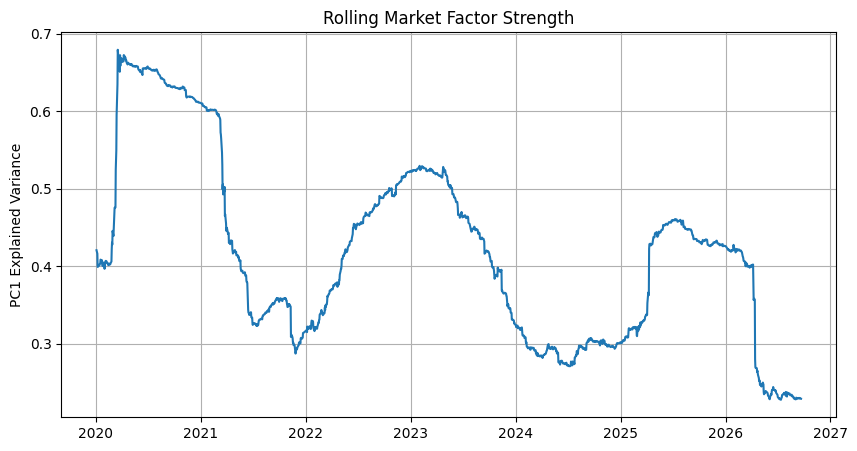

In [33]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    rolling_pca_structure.index,
    rolling_pca_structure["pc1_share"]
)

ax1.set_ylabel("PC1 Explained Variance")
ax1.set_title("Rolling Market Factor Strength")
ax1.grid()

plt.show()

In [34]:
# Past-only regime threshold:
# compare today's PC1 share with the median
# of the PREVIOUS 252 trading days.

pc1_share = rolling_pca_structure["pc1_share"]

pc1_threshold = (
    pc1_share
    .shift(1)
    .rolling(
        window=252,
        min_periods=252
    )
    .median()
)

high_pc1_regime = (
    pc1_share > pc1_threshold
)

# final_perf return at date t+1 comes from
# portfolio chosen using information at date t.
#
# Therefore shift regime by one trading day
# to align it with realized portfolio return.

regime_for_return = (
    high_pc1_regime
    .reindex(stock_returns.index)
    .shift(1)
    .reindex(final_perf.index)
)

regime_test = final_perf[
    ["gross_return", "net_return"]
].copy()

regime_test["high_pc1_regime"] = regime_for_return

regime_test = regime_test.dropna()

regime_test.head()

,gross_return,net_return,high_pc1_regime
date,,,
2021-03-03,0.0,0.0,False
2021-03-04,0.0,0.0,False
2021-03-05,0.0,0.0,False
2021-03-08,0.0,0.0,False
2021-03-09,0.0,0.0,False


In [35]:
rows = []

for regime_name, flag in [
    ("high_pc1", True),
    ("low_pc1", False)
]:

    x = regime_test[
        regime_test["high_pc1_regime"] == flag
    ]

    rows.append({
        "regime": regime_name,

        "days": len(x),

        "avg_gross_return":
            x["gross_return"].mean(),

        "avg_net_return":
            x["net_return"].mean(),

        "gross_sharpe":
            np.sqrt(252)
            * x["gross_return"].mean()
            / x["gross_return"].std(ddof=1),

        "net_sharpe":
            np.sqrt(252)
            * x["net_return"].mean()
            / x["net_return"].std(ddof=1),

        "positive_net_days":
            (x["net_return"] > 0).mean()
    })

regime_diagnostic = pd.DataFrame(rows)

regime_diagnostic

,regime,days,avg_gross_return,avg_net_return,gross_sharpe,net_sharpe,positive_net_days
0,high_pc1,589,0.000115,0.000077,1.12304,0.754676,0.415959
1,low_pc1,806,-0.000007,-0.000007,-0.36041,-0.375535,0.007444


# Switch regime added

In [36]:
regime_results = run_backtest(
    stock_returns=stock_returns,

    pca_window=252,
    k=6,

    spread_window=40,

    signal_mode="zscore",
    z_window=252,
    entry_z=2.5,

    use_ar1_filter=False,

    use_pc1_regime_filter=True,
    regime_window=252,
    regime_quantile=0.50,

    max_holding=20,
    position_size=0.10,
    max_positions=5,

    max_gross=0.50,
    cost_bps=10,
    rebalance_interval=20
)

regime_perf = regime_results["performance"]

performance_summary(regime_perf)

Cumulative Return           0.039776
Annualized Volatility       0.017069
Sharpe Ratio                0.421338
Max Drawdown               -0.029094
Average Daily Turnover      0.016110
Total Transaction Costs     0.022473
Average Gross Exposure      0.112716
Average Active Positions    0.782079
dtype: float64

In [37]:
baseline_results = run_backtest(
    stock_returns=stock_returns,

    pca_window=252,
    k=6,

    spread_window=40,

    signal_mode="zscore",
    z_window=252,
    entry_z=2.5,

    use_ar1_filter=False,

    use_pc1_regime_filter=False,

    max_holding=20,
    position_size=0.10,
    max_positions=5,

    max_gross=0.50,
    cost_bps=10,
    rebalance_interval=20
)

baseline_perf = baseline_results["performance"]

comparison = pd.DataFrame({
    "baseline":
        performance_summary(
            baseline_perf
        ),

    "pc1_regime_filter":
        performance_summary(
            regime_perf
        )
})

comparison

,baseline,pc1_regime_filter
Cumulative Return,-0.002782,0.039776
Annualized Volatility,0.024250,0.017069
Sharpe Ratio,-0.008639,0.421338
Max Drawdown,-0.050436,-0.029094
Average Daily Turnover,0.037058,0.016110
Total Transaction Costs,0.051696,0.022473
Average Gross Exposure,0.249332,0.112716
Average Active Positions,1.779928,0.782079


In [38]:
configs = [
    {
        "name": "zscore",
        "signal_mode": "zscore",
        "use_regime": False,
        "lower_q": 0.025,
        "upper_q": 0.975
    },

    {
        "name": "zscore + PC1 regime",
        "signal_mode": "zscore",
        "use_regime": True,
        "lower_q": 0.025,
        "upper_q": 0.975
    },

    {
        "name": "quantile 2.5/97.5",
        "signal_mode": "quantile",
        "use_regime": False,
        "lower_q": 0.025,
        "upper_q": 0.975
    },

    {
        "name": "quantile 2.5/97.5 + PC1 regime",
        "signal_mode": "quantile",
        "use_regime": True,
        "lower_q": 0.025,
        "upper_q": 0.975
    }
]

comparison_results = {}

for config in configs:

    r = run_backtest(
        stock_returns=stock_returns,

        pca_window=252,
        k=6,

        spread_window=40,

        signal_mode=config["signal_mode"],
        z_window=252,
        entry_z=2.5,

        lower_q=config["lower_q"],
        upper_q=config["upper_q"],

        use_ar1_filter=False,

        use_pc1_regime_filter=config["use_regime"],
        regime_window=252,
        regime_quantile=0.50,

        max_holding=20,
        position_size=0.10,
        max_positions=5,

        max_gross=0.50,
        cost_bps=10,
        rebalance_interval=20
    )

    perf = r["performance"]

    comparison_results[
        config["name"]
    ] = performance_summary(perf)

signal_regime_comparison = pd.DataFrame(
    comparison_results
)

signal_regime_comparison

,zscore,zscore + PC1 regime,quantile 2.5/97.5,quantile 2.5/97.5 + PC1 regime
Cumulative Return,-0.002782,0.039776,-0.009228,0.017427
Annualized Volatility,0.024250,0.017069,0.031230,0.021158
Sharpe Ratio,-0.008639,0.421338,-0.038015,0.158086
Max Drawdown,-0.050436,-0.029094,-0.067984,-0.049117
Average Daily Turnover,0.037058,0.016110,0.070358,0.030916
Total Transaction Costs,0.051696,0.022473,0.098149,0.043127
Average Gross Exposure,0.249332,0.112716,0.435521,0.190532
Average Active Positions,1.779928,0.782079,3.827240,1.630108


In [39]:
experiments = []

# --------------------------------------------------
# 1. Position concentration
# --------------------------------------------------

for max_pos, pos_size in [
    (10, 0.05),
    (5, 0.10),
]:

    experiments.append({
        "test": f"positions_{max_pos}x{pos_size}",
        "H": 40,
        "max_holding": 20,
        "rebalance": 20,
        "max_positions": max_pos,
        "position_size": pos_size
    })


# --------------------------------------------------
# 2. Max holding
# --------------------------------------------------

for holding in [10, 20, 40]:

    experiments.append({
        "test": f"holding_{holding}",
        "H": 40,
        "max_holding": holding,
        "rebalance": 20,
        "max_positions": 5,
        "position_size": 0.10
    })


# --------------------------------------------------
# 3. Rebalance frequency
# --------------------------------------------------

for rebalance in [10, 20, 40]:

    experiments.append({
        "test": f"rebalance_{rebalance}",
        "H": 40,
        "max_holding": 20,
        "rebalance": rebalance,
        "max_positions": 5,
        "position_size": 0.10
    })


# --------------------------------------------------
# 4. Spread horizon robustness
# --------------------------------------------------

for H in [30, 40, 50, 60]:

    experiments.append({
        "test": f"H_{H}",
        "H": H,
        "max_holding": 20,
        "rebalance": 20,
        "max_positions": 5,
        "position_size": 0.10
    })


rows = []

for exp in experiments:

    r = run_backtest(
        stock_returns=stock_returns,

        pca_window=252,
        k=6,

        spread_window=exp["H"],

        signal_mode="zscore",
        z_window=252,
        entry_z=2.5,

        use_ar1_filter=False,

        use_pc1_regime_filter=True,
        regime_window=252,
        regime_quantile=0.50,

        max_holding=exp["max_holding"],
        position_size=exp["position_size"],
        max_positions=exp["max_positions"],

        max_gross=0.50,
        cost_bps=10,
        rebalance_interval=exp["rebalance"]
    )

    perf = r["performance"]
    summary = performance_summary(perf)

    rows.append({
        "test": exp["test"],
        "return": summary["Cumulative Return"],
        "sharpe": summary["Sharpe Ratio"],
        "max_drawdown": summary["Max Drawdown"],
        "turnover": perf["turnover"].mean(),
        "avg_positions": perf["active_positions"].mean()
    })


robustness_test = pd.DataFrame(rows)

robustness_test

,test,return,sharpe,max_drawdown,turnover,avg_positions
0,positions_10x0.05,0.023644,0.464658,-0.015443,0.008848,0.833692
1,positions_5x0.1,0.039776,0.421338,-0.029094,0.016110,0.782079
2,holding_10,0.030514,0.383292,-0.027662,0.021994,0.556989
3,holding_20,0.039776,0.421338,-0.029094,0.016110,0.782079
4,holding_40,0.045883,0.462034,-0.022612,0.012574,1.021505
5,rebalance_10,0.042384,0.449615,-0.028991,0.016428,0.782079
6,rebalance_20,0.039776,0.421338,-0.029094,0.016110,0.782079
7,rebalance_40,0.039776,0.421338,-0.029094,0.016110,0.782079
8,H_30,-0.021172,-0.225756,-0.047509,0.014062,0.721708
9,H_40,0.039776,0.421338,-0.029094,0.016110,0.782079


In [40]:
configs = [
    {
        "name": "10x5_hold20",
        "max_positions": 10,
        "position_size": 0.05,
        "max_holding": 20
    },
    {
        "name": "10x5_hold40",
        "max_positions": 10,
        "position_size": 0.05,
        "max_holding": 40
    },
    {
        "name": "5x10_hold20",
        "max_positions": 5,
        "position_size": 0.10,
        "max_holding": 20
    },
    {
        "name": "5x10_hold40",
        "max_positions": 5,
        "position_size": 0.10,
        "max_holding": 40
    }
]

rows = []

for config in configs:

    r = run_backtest(
        stock_returns=stock_returns,

        pca_window=252,
        k=6,

        spread_window=40,

        signal_mode="zscore",
        z_window=252,
        entry_z=2.5,

        use_ar1_filter=False,

        use_pc1_regime_filter=True,
        regime_window=252,
        regime_quantile=0.50,

        max_holding=config["max_holding"],
        position_size=config["position_size"],
        max_positions=config["max_positions"],

        max_gross=0.50,
        cost_bps=10,
        rebalance_interval=20
    )

    perf = r["performance"]

    summary = performance_summary(perf)

    rows.append({
        "config": config["name"],
        "return": summary["Cumulative Return"],
        "sharpe": summary["Sharpe Ratio"],
        "max_drawdown": summary["Max Drawdown"],
        "turnover": perf["turnover"].mean(),
        "avg_positions": perf["active_positions"].mean(),
        "avg_gross_exposure": perf["gross_exposure"].mean()
    })

interaction_test = pd.DataFrame(rows)

interaction_test

,config,return,sharpe,max_drawdown,turnover,avg_positions,avg_gross_exposure
0,10x5_hold20,0.023644,0.464658,-0.015443,0.008848,0.833692,0.059530
1,10x5_hold40,0.035006,0.591790,-0.015430,0.007207,1.122581,0.075879
2,5x10_hold20,0.039776,0.421338,-0.029094,0.016110,0.782079,0.112716
3,5x10_hold40,0.045883,0.462034,-0.022612,0.012574,1.021505,0.141059
